# Comparing CNN Architectures for Breast Cancer Histopathology Classification"

_Data was manually downloaded from BACH's offifical website which includes 400 photos of H&E-stained pathology images sampled from breast tissues. These images play a significant role in detecting differet types of cancer early. It includes 4 different types: **Normal**, **Benign**, **InSitu**, **Invasive**. We will scale up our training if necessary. In this version, I had to change the model structure and trainer to make it more accurate and reproducible. In this analysis we will be comparing the difference in performance between ResNet50 and ResNet18._

### Importing required libraries

In [2]:
import os 
import torch
import cv2
import csv
import time
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm 
import torchvision.transforms.functional as TF


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
class config:
    batchsize = 8
    num_epochs = 30
    learning_rate = 1e-4
    num_classes = 4

In [5]:
pd.set_option('future.no_silent_downcasting', True)

# Data Preprocessing and Preparation

In [6]:
dataset_path = "/Users/parshangerafian/HE-classification/Photos"
csv_path = "/Users/parshangerafian/HE-classification/Photos/microscopy_ground_truth.csv"

df = pd.read_csv(csv_path)
image_paths, labels = [], []

for class_name in ["Benign", "InSitu", "Invasive", "Normal"]:
    class_path = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_path):
        if img_name.endswith(".tif"):  
            image_paths.append(os.path.join(class_path, img_name))
            labels.append(class_name)


image_df = pd.DataFrame({"image_path": image_paths, "label": labels})

image_df["label"] = image_df["label"].replace({"Normal": 0, "Benign": 1, "InSitu": 2, "Invasive": 3}).astype("int64")
image_df = image_df.sample(frac=1, random_state=42).reset_index(drop=True)
image_df.to_csv("bach_training_data.csv", index=False)

dataset = pd.read_csv("bach_training_data.csv")
dataset.head()

,image_path,label
0,/Users/parshangerafian/HE-classification/Photo...,3
1,/Users/parshangerafian/HE-classification/Photo...,3
2,/Users/parshangerafian/HE-classification/Photo...,1
3,/Users/parshangerafian/HE-classification/Photo...,3
4,/Users/parshangerafian/HE-classification/Photo...,1


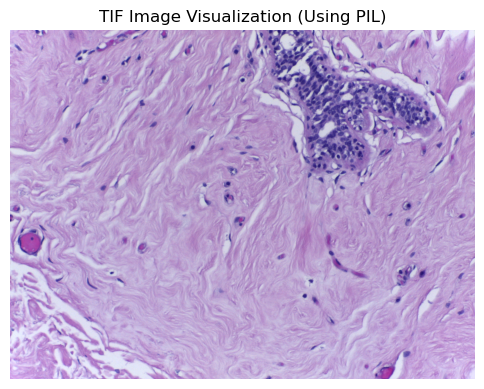

In [7]:
#An example of our dataset
tif_file_path = "/Users/parshangerafian/HE-classification/Photos/Benign/b001.tif"
image = Image.open(tif_file_path)
image_array = np.array(image)
plt.figure(figsize=(6, 6))
plt.imshow(image_array)
plt.title("TIF Image Visualization (Using PIL)")
plt.axis("off")  
plt.show()

In [8]:
class BACHDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]["image_path"]
        label = torch.tensor(self.data.iloc[idx]["label"], dtype=torch.long)
        image = Image.open(img_path).convert("RGB")
        image = cv2.resize(np.array(image), (224, 224), interpolation=cv2.INTER_AREA)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)  

        return image, label

class MinMaxScalerTransform: #This is used for normalizing our dataset
    def __call__(self, img):
        img_array = np.array(img).astype(np.float32) / 255.0
        return torch.tensor(img_array).permute(2, 0, 1)

data_transforms = transforms.Compose([
    MinMaxScalerTransform(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

## Data Loaders

In [9]:
train, temp = train_test_split(dataset, test_size=0.3, stratify=dataset["label"], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["label"], random_state=42)

train_dataset = BACHDataset(train, transform=data_transforms)
val_dataset = BACHDataset(val, transform=None)
test_dataset = BACHDataset(test, transform=None)

train_dataloader = DataLoader(train_dataset, batch_size=config.batchsize, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=config.batchsize, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=config.batchsize, shuffle=True)

## Visualise Samples


Train Samples - Total Batches: 35 | Total Samples: 280


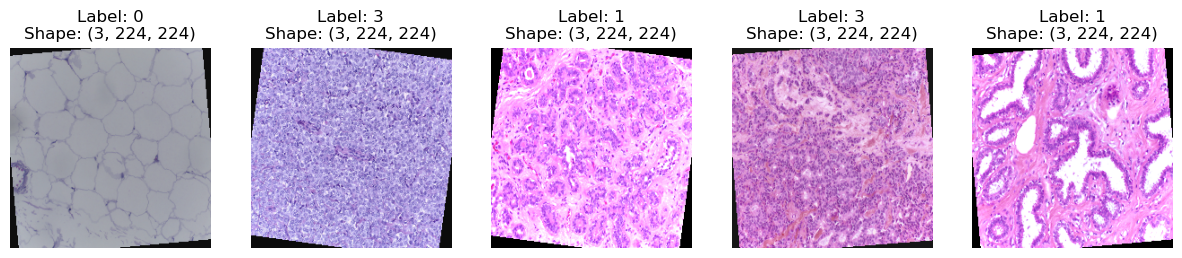


Validation Samples - Total Batches: 8 | Total Samples: 60


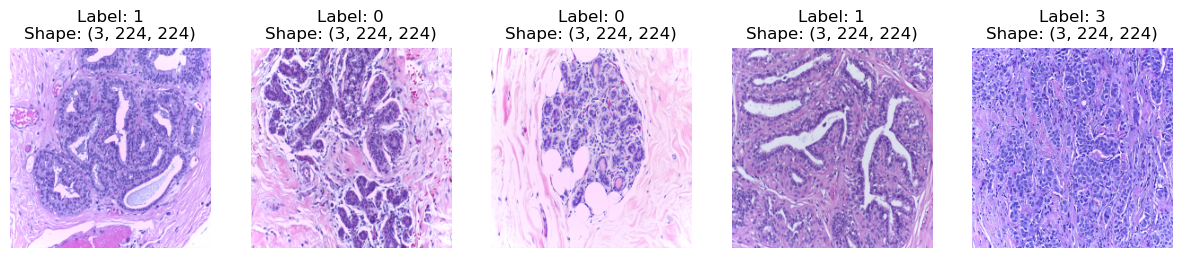


Test Samples - Total Batches: 8 | Total Samples: 60


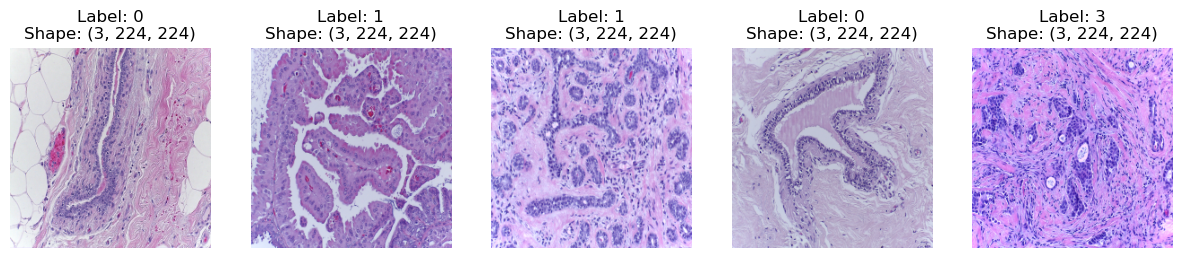

In [10]:
def show_samples(dataloader, title, num_samples=5):
    print(f"\n{title} - Total Batches: {len(dataloader)} | Total Samples: {len(dataloader.dataset)}")


    batch = next(iter(dataloader))

    if isinstance(batch, tuple) and len(batch) == 2: 
        images, labels = batch
    elif isinstance(batch, list) and len(batch) == 2:
        images, labels = batch[0], batch[1]
    else:
        raise ValueError(f"Unexpected batch format from DataLoader: {type(batch)}, content: {batch}")

   
    if isinstance(images, list):
        images = torch.stack(images)
    
    
    if images.ndim == 3:
        images = images.unsqueeze(0) 

    num_samples = min(num_samples, images.shape[0]) 


    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]  
    for i in range(num_samples):
        img_tensor = images[i] 
        img = TF.to_pil_image(img_tensor.cpu())  
        label = labels[i].item() if isinstance(labels[i], torch.Tensor) else labels[i]
        img_shape = tuple(img_tensor.shape)  

        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}\nShape: {img_shape}")  
        axes[i].axis("off")

      

    plt.show()

show_samples(train_dataloader, "Train Samples")
show_samples(val_dataloader, "Validation Samples")
show_samples(test_dataloader, "Test Samples")

# ML Model Construction and Workflow development

## ResNet18 Model

ResNet18 is a variant of the Residual Network (ResNet) architecture, which was introduced to adress the vanishing gradient problem in deep neural networks. The architecture is designed to allow networks to be deeper, thus improving their ability to learn complex patterns in data. The Resnet18 model consits of 18 layers, including convolutional layers and residual blocks. Residual blocks are the core component of ResNet architecures, and they include skip connections tha bypass one or more layers. A residual block allows the input to bypass one or more layers via a shortcut cnnection, which helps in mitigating the vainishing gradient problem. This is achieved by learning the residual mapping instead of the original mapping. A typical residual block in ResNet18 consists of two convolutional layers with batch normalization and ReLU activation.

In [11]:
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


In [12]:
class ResNet18Custom(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super(ResNet18Custom, self).__init__()
        
        # Load pretrained ResNet18 model
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze layers 1-3
        for param in self.model.layer1.parameters():
            param.requires_grad = False
        for param in self.model.layer2.parameters():
            param.requires_grad = False
        for param in self.model.layer3.parameters():
            param.requires_grad = False
        # Leave layer4 trainable

        # Get the number of features from the last FC layer
        num_features = self.model.fc.in_features

        # Replace FC head with custom classifier
        self.model.fc = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate - 0.1),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

## ResNet50 Model
In this version, I modified the trainer and models significantly. I have added **ReduceLROnPlateau** - a scheduler that reduces the learning rate using patience, used different number of epochs, and used weighted cross entropy loss at the end. Therefore, our hyperparameter tuning is included in this section and the weighted cross entropy loss section. I also included new metrics including Recall, Precision, and F1 score.

In [13]:
class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return self.relu(out)

class ResNet50CustomBuild(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50CustomBuild, self).__init__()
        
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(Bottleneck, 64, 3)
        self.layer2 = self._make_layer(Bottleneck, 128, 4, stride=2)
        self.layer3 = self._make_layer(Bottleneck, 256, 6, stride=2)
        self.layer4 = self._make_layer(Bottleneck, 512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = [block(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


In [14]:
import torch
import torch.nn as nn
import torchvision.models as models

class ResNet50Custom(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super(ResNet50Custom, self).__init__()
        
        # Load pretrained model
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze layers 1-3
        for param in self.model.layer1.parameters():
            param.requires_grad = False
        for param in self.model.layer2.parameters():
            param.requires_grad = False
        for param in self.model.layer3.parameters():
            param.requires_grad = False
        # Keep layer4 trainable

        # Get in_features of last FC layer
        num_features = self.model.fc.in_features

        # Replace the classifier
        self.model.fc = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate - 0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = ResNet50Custom(num_classes=4).to(device)


criterion = nn.CrossEntropyLoss()


class_weights = torch.tensor([1.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device)  


criterion_w = nn.CrossEntropyLoss(weight=class_weights)


optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5, verbose=True
)

/usr/local/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


### Early stopping Class

In [15]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta

    def __call__(self, val_loss):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

#### I added Early stopping for last regularization techniques and last tries to improve the model.

## ResNet-50 Trainer devlopment

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm
import time
import csv
import matplotlib.pyplot as plt

class ResNet50Trainer:
    def __init__(self, num_classes, device, config):
        self.num_classes = num_classes
        self.device = device
        self.config = config

        self.model = self.build_model().to(device)

        self.class_weights = torch.tensor([1.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device)
        self.criterion = nn.CrossEntropyLoss()
        self.criterion_w = nn.CrossEntropyLoss(weight=self.class_weights) #Weighted Cross Entropy Loss
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', patience=3, factor=0.5)

    def build_model(self):
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for param in model.layer1.parameters(): param.requires_grad = False
        for param in model.layer2.parameters(): param.requires_grad = False
        for param in model.layer3.parameters(): param.requires_grad = False

        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, self.num_classes)
        )
        return model

    def convert_to_one_hot(self, label):
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(label)
        return F.one_hot(label.clone().detach(), self.num_classes).float()

    def compute_metrics(self, preds_list, labels_list):
        labels_list = [int(lbl) if isinstance(lbl, torch.Tensor) else lbl for lbl in labels_list]
        TP = torch.zeros(self.num_classes)
        TN = torch.zeros(self.num_classes)
        FP = torch.zeros(self.num_classes)
        FN = torch.zeros(self.num_classes)
        correct = 0

        for preds, label in zip(preds_list, labels_list):
            label_one_hot = self.convert_to_one_hot(label)
            pred_class = torch.argmax(preds) if preds.dim() > 0 else preds
            pred_one_hot = self.convert_to_one_hot(pred_class)

            if pred_class == label:
                correct += 1

            for i in range(self.num_classes):
                TP[i] += int(pred_one_hot[i] == 1 and label_one_hot[i] == 1)
                TN[i] += int(pred_one_hot[i] == 0 and label_one_hot[i] == 0)
                FP[i] += int(pred_one_hot[i] == 1 and label_one_hot[i] == 0)
                FN[i] += int(pred_one_hot[i] == 0 and label_one_hot[i] == 1)

        precision = TP / (TP + FP).clamp(min=1e-10)
        recall = TP / (TP + FN).clamp(min=1e-10)
        specificity = TN / (TN + FP).clamp(min=1e-10)
        f1 = 2 * (precision * recall) / (precision + recall).clamp(min=1e-10)

        return {
            "accuracy": correct / len(labels_list),
            "precision_per_class": precision.tolist(),
            "macro_precision": precision.mean().item(),
            "recall_per_class": recall.tolist(),
            "macro_recall": recall.mean().item(),
            "specificity_per_class": specificity.tolist(),
            "macro_specificity": specificity.mean().item(),
            "f1_score_per_class": f1.tolist(),
            "macro_f1_score": f1.mean().item(),
        }

    def plot_loss(self, train_losses, val_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.grid(True)
        plt.show()

    def train(self, train_loader, val_loader, model_path, csv_name, use_weighted_loss=False):
        log_fields = ["epoch", "time", "train_loss", "val_loss", "train_precision", "val_precision", 
                      "train_recall", "val_recall", "train_F1_Score", "val_F1_Score"]
        best_f1 = 0
        total_time = 0
        train_losses, val_losses = [], []
        early_stopping = EarlyStopping(patience=7)

        with open(csv_name, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=log_fields).writeheader()

        for epoch in range(self.config.num_epochs):
            start_time = time.time()
            self.model.train()

            total_loss, correct, total = 0, 0, 0
            preds_list, labels_list = [], []
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = (self.criterion if not use_weighted_loss else self.criterion_w)(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                preds_list.append(probs.cpu())
                labels_list.append(labels.cpu())

            train_loss = total_loss / len(train_loader)
            train_losses.append(train_loss)
            train_metrics = self.compute_metrics(torch.cat(preds_list), torch.cat(labels_list))

            print(f"\n--- Training Metrics (Epoch {epoch+1}) ---")
            print(f"Train Loss: {train_loss:.4f}")
            print(f"Accuracy: {train_metrics['accuracy']:.4f}")
            print(f"Macro Precision: {train_metrics['macro_precision']:.4f}")
            print(f"Macro Recall: {train_metrics['macro_recall']:.4f}")
            print(f"Macro F1 Score: {train_metrics['macro_f1_score']:.4f}")
            for class_idx in range(self.num_classes):
                print(f"Class {class_idx} - Precision: {train_metrics['precision_per_class'][class_idx]:.4f}, "
                      f"Recall: {train_metrics['recall_per_class'][class_idx]:.4f}, "
                      f"F1-score: {train_metrics['f1_score_per_class'][class_idx]:.4f}")

            val_preds, val_labels, val_acc, val_loss = self.validate(val_loader, epoch)
            val_losses.append(val_loss)
            val_metrics = self.compute_metrics(val_preds, val_labels)

            print(f"\n--- Validation Metrics (Epoch {epoch+1}) ---")
            print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
            print(f"Macro Precision: {val_metrics['macro_precision']:.4f}")
            print(f"Macro Recall: {val_metrics['macro_recall']:.4f}")
            print(f"Macro F1 Score: {val_metrics['macro_f1_score']:.4f}")
            for class_idx in range(self.num_classes):
                print(f"Class {class_idx} - Precision: {val_metrics['precision_per_class'][class_idx]:.4f}, "
                      f"Recall: {val_metrics['recall_per_class'][class_idx]:.4f}, "
                      f"F1-score: {val_metrics['f1_score_per_class'][class_idx]:.4f}")

            total_time += time.time() - start_time
            if val_metrics['macro_f1_score'] > best_f1:
                best_f1 = val_metrics['macro_f1_score']
                torch.save(self.model.state_dict(), model_path)

            with open(csv_name, 'a', newline='', encoding='utf-8') as f:
                csv.DictWriter(f, fieldnames=log_fields).writerow({
                    "epoch": epoch + 1, "time": round(time.time() - start_time, 2),
                    "train_loss": round(train_loss, 4), "val_loss": round(val_loss, 4),
                    "train_precision": round(train_metrics['macro_precision'], 4),
                    "val_precision": round(val_metrics['macro_precision'], 4),
                    "train_recall": round(train_metrics['macro_recall'], 4),
                    "val_recall": round(val_metrics['macro_recall'], 4),
                    "train_F1_Score": round(train_metrics['macro_f1_score'], 4),
                    "val_F1_Score": round(val_metrics['macro_f1_score'], 4)
                })
            early_stopping(val_loss)
            if early_stopping.early_stop:
                print("Early stopping triggered.")
                break

        self.plot_loss(train_losses, val_losses)

    def validate(self, val_loader, epoch):
        self.model.eval()
        val_loss, correct, total = 0, 0, 0
        preds_list, labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Val Epoch {epoch + 1}"):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                val_loss += loss.item()
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                preds_list.append(probs.cpu())
                labels_list.append(labels.cpu())
        self.scheduler.step(val_loss / len(val_loader))
        return torch.cat(preds_list), torch.cat(labels_list), correct / total, val_loss / len(val_loader)

    def inference(self, model_path, dataloader):
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device).eval()
        preds_list, labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(dataloader, desc="Inference"):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        metrics = self.compute_metrics(torch.cat(preds_list), torch.cat(labels_list))
        print(f"\nMacro Precision: {metrics['macro_precision']:.4f}, Macro Recall: {metrics['macro_recall']:.4f}, Macro F1: {metrics['macro_f1_score']:.4f}")
        for class_idx in range(self.num_classes):
            print(f"Class {class_idx} - Precision: {metrics['precision_per_class'][class_idx]:.4f}, "
                  f"Recall: {metrics['recall_per_class'][class_idx]:.4f}, "
                  f"F1-score: {metrics['f1_score_per_class'][class_idx]:.4f}")
        #Plot confusion matrix
        cm = confusion_matrix(torch.cat(labels_list), torch.cat(preds_list))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()

## ResNet 18 Trainer Development

In [17]:
class ResNet18Trainer:
    def __init__(self, num_classes, device, config):
        self.num_classes = num_classes
        self.device = device
        self.config = config

        self.model = self.build_model().to(device)

        self.class_weights = torch.tensor([1.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device)
        self.criterion = nn.CrossEntropyLoss(weight=self.class_weights)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', patience=3, factor=0.5)

    def build_model(self):
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for param in model.layer1.parameters(): param.requires_grad = False
        for param in model.layer2.parameters(): param.requires_grad = False
        for param in model.layer3.parameters(): param.requires_grad = False

        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, self.num_classes)
        )
        return model

    def convert_to_one_hot(self, label):
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(label)
        return F.one_hot(label.clone().detach(), self.num_classes).float()

    def compute_metrics(self, preds_list, labels_list):
        labels_list = [int(lbl) if isinstance(lbl, torch.Tensor) else lbl for lbl in labels_list]
        TP = torch.zeros(self.num_classes)
        TN = torch.zeros(self.num_classes)
        FP = torch.zeros(self.num_classes)
        FN = torch.zeros(self.num_classes)
        correct = 0

        for preds, label in zip(preds_list, labels_list):
            label_one_hot = self.convert_to_one_hot(label)
            pred_class = torch.argmax(preds) if preds.dim() > 0 else preds
            pred_one_hot = self.convert_to_one_hot(pred_class)

            if pred_class == label:
                correct += 1

            for i in range(self.num_classes):
                TP[i] += int(pred_one_hot[i] == 1 and label_one_hot[i] == 1)
                TN[i] += int(pred_one_hot[i] == 0 and label_one_hot[i] == 0)
                FP[i] += int(pred_one_hot[i] == 1 and label_one_hot[i] == 0)
                FN[i] += int(pred_one_hot[i] == 0 and label_one_hot[i] == 1)

        precision = TP / (TP + FP).clamp(min=1e-10)
        recall = TP / (TP + FN).clamp(min=1e-10)
        specificity = TN / (TN + FP).clamp(min=1e-10)
        f1 = 2 * (precision * recall) / (precision + recall).clamp(min=1e-10)

        return {
            "accuracy": correct / len(labels_list),
            "precision_per_class": precision.tolist(),
            "macro_precision": precision.mean().item(),
            "recall_per_class": recall.tolist(),
            "macro_recall": recall.mean().item(),
            "specificity_per_class": specificity.tolist(),
            "macro_specificity": specificity.mean().item(),
            "f1_score_per_class": f1.tolist(),
            "macro_f1_score": f1.mean().item(),
        }

    def plot_loss(self, train_losses, val_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.grid(True)
        plt.show()

    def train(self, train_loader, val_loader, model_path, csv_name, use_weighted_loss=False):
        log_fields = ["epoch", "time", "train_loss", "val_loss", "train_precision", "val_precision", 
                      "train_recall", "val_recall", "train_F1_Score", "val_F1_Score"]
        best_f1 = 0
        total_time = 0
        train_losses, val_losses = [], []
        early_stopping = EarlyStopping(patience=7)

        with open(csv_name, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=log_fields).writeheader()

        for epoch in range(self.config.num_epochs):
            start_time = time.time()
            self.model.train()

            total_loss, correct, total = 0, 0, 0
            preds_list, labels_list = [], []
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = (self.criterion if not use_weighted_loss else nn.CrossEntropyLoss(weight=self.class_weights))(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                preds_list.append(probs.cpu())
                labels_list.append(labels.cpu())

            train_loss = total_loss / len(train_loader)
            train_losses.append(train_loss)
            train_metrics = self.compute_metrics(torch.cat(preds_list), torch.cat(labels_list))

            print(f"\n--- Training Metrics (Epoch {epoch+1}) ---")
            print(f"Train Loss: {train_loss:.4f}")
            print(f"Accuracy: {train_metrics['accuracy']:.4f}")
            print(f"Macro Precision: {train_metrics['macro_precision']:.4f}")
            print(f"Macro Recall: {train_metrics['macro_recall']:.4f}")
            print(f"Macro F1 Score: {train_metrics['macro_f1_score']:.4f}")
            for class_idx in range(self.num_classes):
                print(f"Class {class_idx} - Precision: {train_metrics['precision_per_class'][class_idx]:.4f}, "
                      f"Recall: {train_metrics['recall_per_class'][class_idx]:.4f}, "
                      f"F1-score: {train_metrics['f1_score_per_class'][class_idx]:.4f}")

            val_preds, val_labels, val_acc, val_loss = self.validate(val_loader, epoch)
            val_losses.append(val_loss)
            val_metrics = self.compute_metrics(val_preds, val_labels)

            print(f"\n--- Validation Metrics (Epoch {epoch+1}) ---")
            print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
            print(f"Macro Precision: {val_metrics['macro_precision']:.4f}")
            print(f"Macro Recall: {val_metrics['macro_recall']:.4f}")
            print(f"Macro F1 Score: {val_metrics['macro_f1_score']:.4f}")
            for class_idx in range(self.num_classes):
                print(f"Class {class_idx} - Precision: {val_metrics['precision_per_class'][class_idx]:.4f}, "
                      f"Recall: {val_metrics['recall_per_class'][class_idx]:.4f}, "
                      f"F1-score: {val_metrics['f1_score_per_class'][class_idx]:.4f}")

            total_time += time.time() - start_time
            if val_metrics['macro_f1_score'] > best_f1:
                best_f1 = val_metrics['macro_f1_score']
                torch.save(self.model.state_dict(), model_path)

            with open(csv_name, 'a', newline='', encoding='utf-8') as f:
                csv.DictWriter(f, fieldnames=log_fields).writerow({
                    "epoch": epoch + 1, "time": round(time.time() - start_time, 2),
                    "train_loss": round(train_loss, 4), "val_loss": round(val_loss, 4),
                    "train_precision": round(train_metrics['macro_precision'], 4),
                    "val_precision": round(val_metrics['macro_precision'], 4),
                    "train_recall": round(train_metrics['macro_recall'], 4),
                    "val_recall": round(val_metrics['macro_recall'], 4),
                    "train_F1_Score": round(train_metrics['macro_f1_score'], 4),
                    "val_F1_Score": round(val_metrics['macro_f1_score'], 4)
                })

        self.plot_loss(train_losses, val_losses)

    def validate(self, val_loader, epoch):
        self.model.eval()
        val_loss, correct, total = 0, 0, 0
        preds_list, labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Val Epoch {epoch + 1}"):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                val_loss += loss.item()
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                preds_list.append(probs.cpu())
                labels_list.append(labels.cpu())
        self.scheduler.step(val_loss / len(val_loader))
        return torch.cat(preds_list), torch.cat(labels_list), correct / total, val_loss / len(val_loader)

    def inference(self, model_path, dataloader):
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device).eval()
        preds_list, labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(dataloader, desc="Inference"):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        metrics = self.compute_metrics(torch.cat(preds_list), torch.cat(labels_list))
        print(f"\nMacro Precision: {metrics['macro_precision']:.4f}, Macro Recall: {metrics['macro_recall']:.4f}, Macro F1: {metrics['macro_f1_score']:.4f}")
        for class_idx in range(self.num_classes):
            print(f"Class {class_idx} - Precision: {metrics['precision_per_class'][class_idx]:.4f}, "
                  f"Recall: {metrics['recall_per_class'][class_idx]:.4f}, "
                  f"F1-score: {metrics['f1_score_per_class'][class_idx]:.4f}")
        #Plot confusion matrix
        cm = confusion_matrix(torch.cat(labels_list), torch.cat(preds_list))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()

# ResNet-18 Model Training

## ResNet-18 model training with ***Weighted*** Cross Entropy Loss

Epoch 1: 100%|██████████| 40/40 [00:57<00:00,  1.44s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3519
Accuracy: 0.3312
Macro Precision: 0.3474
Macro Recall: 0.3313
Macro F1 Score: 0.3221
Class 0 - Precision: 0.3412, Recall: 0.3625, F1-score: 0.3515
Class 1 - Precision: 0.3226, Recall: 0.3750, F1-score: 0.3468
Class 2 - Precision: 0.3063, Recall: 0.4250, F1-score: 0.3560
Class 3 - Precision: 0.4194, Recall: 0.1625, F1-score: 0.2342


Val Epoch 1: 100%|██████████| 8/8 [00:05<00:00,  1.35it/s]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.2664, Accuracy: 0.3833
Macro Precision: 0.6182
Macro Recall: 0.3833
Macro F1 Score: 0.3306
Class 0 - Precision: 0.5000, Recall: 0.1333, F1-score: 0.2105
Class 1 - Precision: 0.3061, Recall: 1.0000, F1-score: 0.4688
Class 2 - Precision: 0.6667, Recall: 0.1333, F1-score: 0.2222
Class 3 - Precision: 1.0000, Recall: 0.2667, F1-score: 0.4211


Epoch 2: 100%|██████████| 40/40 [00:52<00:00,  1.30s/it]


...


--- Validation Metrics (Epoch 29) ---
Val Loss: 1.0569, Accuracy: 0.8167
Macro Precision: 0.8373
Macro Recall: 0.8167
Macro F1 Score: 0.8156
Class 0 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 1 - Precision: 0.7368, Recall: 0.9333, F1-score: 0.8235
Class 2 - Precision: 1.0000, Recall: 0.6667, F1-score: 0.8000
Class 3 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000


Epoch 30: 100%|██████████| 40/40 [00:51<00:00,  1.28s/it]



--- Training Metrics (Epoch 30) ---
Train Loss: 0.0177
Accuracy: 0.9938
Macro Precision: 0.9939
Macro Recall: 0.9937
Macro F1 Score: 0.9938
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 0.9756, Recall: 1.0000, F1-score: 0.9877
Class 2 - Precision: 1.0000, Recall: 0.9875, F1-score: 0.9937
Class 3 - Precision: 1.0000, Recall: 0.9875, F1-score: 0.9937


Val Epoch 30: 100%|██████████| 8/8 [00:06<00:00,  1.32it/s]



--- Validation Metrics (Epoch 30) ---
Val Loss: 0.9243, Accuracy: 0.7833
Macro Precision: 0.7943
Macro Recall: 0.7833
Macro F1 Score: 0.7823
Class 0 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 1 - Precision: 0.7222, Recall: 0.8667, F1-score: 0.7879
Class 2 - Precision: 0.9091, Recall: 0.6667, F1-score: 0.7692
Class 3 - Precision: 0.7333, Recall: 0.7333, F1-score: 0.7333


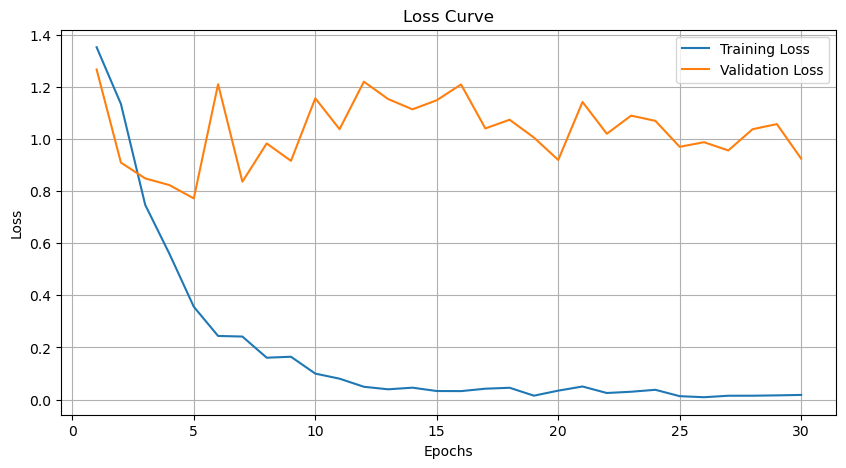

In [26]:
trainer = ResNet18Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model_resnet18_custom.pth",
    csv_name="training_results_resnet18_custom.csv",
    use_weighted_loss=True
)

# ResNet-18 Model Inference with ***Weighted*** Cross Entropy Loss

In [27]:
trainer = ResNet18Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.inference(model_path="best_model_resnet18_custom.pth", dataloader=test_dataloader)

Inference: 100%|██████████| 3/3 [00:01<00:00,  1.69it/s]


Macro Precision: 0.9000, Macro Recall: 0.9000, Macro F1: 0.9000
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 2 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 3 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000


# ResNet-50 Model Training
## Training and Validation with Cross Entropy Loss

Epoch 1: 100%|██████████| 35/35 [01:28<00:00,  2.54s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3831
Accuracy: 0.2750
Macro Precision: 0.4130
Macro Recall: 0.2750
Macro F1 Score: 0.2138
Class 0 - Precision: 0.2667, Recall: 0.0571, F1-score: 0.0941
Class 1 - Precision: 0.2331, Recall: 0.7857, F1-score: 0.3595
Class 2 - Precision: 0.5000, Recall: 0.0429, F1-score: 0.0789
Class 3 - Precision: 0.6522, Recall: 0.2143, F1-score: 0.3226


Val Epoch 1: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.3720, Accuracy: 0.3333
Macro Precision: 0.2778
Macro Recall: 0.3333
Macro F1 Score: 0.2277
Class 0 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 1 - Precision: 0.2778, Recall: 1.0000, F1-score: 0.4348
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.8333, Recall: 0.3333, F1-score: 0.4762


Epoch 2: 100%|██████████| 35/35 [01:15<00:00,  2.15s/it]


...


--- Validation Metrics (Epoch 25) ---
Val Loss: 0.7172, Accuracy: 0.8833
Macro Precision: 0.8867
Macro Recall: 0.8833
Macro F1 Score: 0.8830
Class 0 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571
Class 1 - Precision: 0.8235, Recall: 0.9333, F1-score: 0.8750
Class 2 - Precision: 0.8667, Recall: 0.8667, F1-score: 0.8667
Class 3 - Precision: 0.9333, Recall: 0.9333, F1-score: 0.9333


Epoch 26: 100%|██████████| 35/35 [01:26<00:00,  2.46s/it]



--- Training Metrics (Epoch 26) ---
Train Loss: 0.0490
Accuracy: 0.9857
Macro Precision: 0.9861
Macro Recall: 0.9857
Macro F1 Score: 0.9858
Class 0 - Precision: 1.0000, Recall: 0.9857, F1-score: 0.9928
Class 1 - Precision: 0.9589, Recall: 1.0000, F1-score: 0.9790
Class 2 - Precision: 1.0000, Recall: 0.9857, F1-score: 0.9928
Class 3 - Precision: 0.9855, Recall: 0.9714, F1-score: 0.9784


Val Epoch 26: 100%|██████████| 8/8 [00:08<00:00,  1.01s/it]



--- Validation Metrics (Epoch 26) ---
Val Loss: 0.8183, Accuracy: 0.8500
Macro Precision: 0.8526
Macro Recall: 0.8500
Macro F1 Score: 0.8498
Class 0 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571
Class 1 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 2 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 3 - Precision: 0.8750, Recall: 0.9333, F1-score: 0.9032
Early stopping triggered.


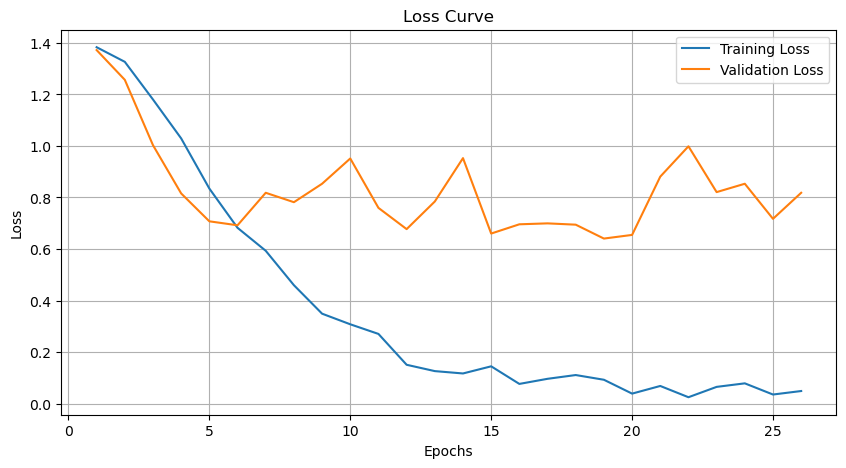

In [18]:
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model2.pth",
    csv_name="training_results2.csv",
    use_weighted_loss=False
)

## ResNet-50 Model Inference (Using Cross Entropy Loss)

In [53]:
best_model_path = "best_model2.pth"
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.inference(model_path=best_model_path, dataloader=test_dataloader)

Inference: 100%|██████████| 3/3 [00:02<00:00,  1.14it/s]


Macro Precision: 0.8042, Macro Recall: 0.8000, Macro F1: 0.7985
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 0.7500, Recall: 0.6000, F1-score: 0.6667
Class 2 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 3 - Precision: 0.6667, Recall: 0.8000, F1-score: 0.7273


# More **Hyperparameter** tuning
## ResNet-50 Training and Validation with ***Weighted*** Cross Entropy Loss 

Epoch 1: 100%|██████████| 40/40 [01:40<00:00,  2.50s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3784
Accuracy: 0.2938
Macro Precision: 0.3669
Macro Recall: 0.2937
Macro F1 Score: 0.2298
Class 0 - Precision: 0.5714, Recall: 0.0500, F1-score: 0.0920
Class 1 - Precision: 0.3725, Recall: 0.2375, F1-score: 0.2901
Class 2 - Precision: 0.2735, Recall: 0.8000, F1-score: 0.4076
Class 3 - Precision: 0.2500, Recall: 0.0875, F1-score: 0.1296


Val Epoch 1: 100%|██████████| 8/8 [00:10<00:00,  1.27s/it]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.3524, Accuracy: 0.3333
Macro Precision: 0.6936
Macro Recall: 0.3333
Macro F1 Score: 0.2676
Class 0 - Precision: 1.0000, Recall: 0.0667, F1-score: 0.1250
Class 1 - Precision: 0.2745, Recall: 0.9333, F1-score: 0.4242
Class 2 - Precision: 0.5000, Recall: 0.2000, F1-score: 0.2857
Class 3 - Precision: 1.0000, Recall: 0.1333, F1-score: 0.2353


Epoch 2: 100%|██████████| 40/40 [01:31<00:00,  2.29s/it]


...


--- Validation Metrics (Epoch 29) ---
Val Loss: 1.0315, Accuracy: 0.8000
Macro Precision: 0.8230
Macro Recall: 0.8000
Macro F1 Score: 0.8021
Class 0 - Precision: 0.6667, Recall: 0.9333, F1-score: 0.7778
Class 1 - Precision: 0.7857, Recall: 0.7333, F1-score: 0.7586
Class 2 - Precision: 0.9167, Recall: 0.7333, F1-score: 0.8148
Class 3 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571


Epoch 30: 100%|██████████| 40/40 [03:25<00:00,  5.14s/it]



--- Training Metrics (Epoch 30) ---
Train Loss: 0.0162
Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1 Score: 1.0000
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 2 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 3 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000


Val Epoch 30: 100%|██████████| 8/8 [00:14<00:00,  1.84s/it]



--- Validation Metrics (Epoch 30) ---
Val Loss: 0.8795, Accuracy: 0.8167
Macro Precision: 0.8330
Macro Recall: 0.8167
Macro F1 Score: 0.8182
Class 0 - Precision: 0.7000, Recall: 0.9333, F1-score: 0.8000
Class 1 - Precision: 0.7857, Recall: 0.7333, F1-score: 0.7586
Class 2 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571
Class 3 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571


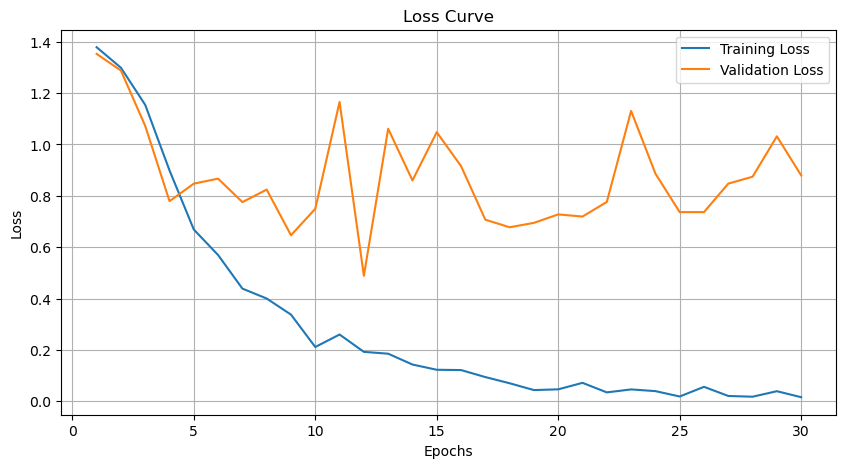

In [37]:
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model1.pth",
    csv_name="training_results1.csv", 
    use_weighted_loss=True
)

## ResNet-50 Model Inference (Using ***Weighted*** Cross Entropy Loss)

In [38]:
best_model_path = "best_model1.pth"
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.inference(model_path=best_model_path, dataloader=test_dataloader)

Inference: 100%|██████████| 3/3 [00:05<00:00,  1.89s/it]


Macro Precision: 0.8583, Macro Recall: 0.8500, Macro F1: 0.8495
Class 0 - Precision: 0.8333, Recall: 1.0000, F1-score: 0.9091
Class 1 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 2 - Precision: 1.0000, Recall: 0.8000, F1-score: 0.8889
Class 3 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000


## ResNet-50 Training 
***Early Stopping*** + ***Weighted Cross Enropy Loss***

Epoch 1: 100%|██████████| 35/35 [01:32<00:00,  2.64s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3682
Accuracy: 0.2500
Macro Precision: 0.0627
Macro Recall: 0.2500
Macro F1 Score: 0.1003
Class 0 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 1 - Precision: 0.2509, Recall: 1.0000, F1-score: 0.4011
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000


Val Epoch 1: 100%|██████████| 8/8 [00:07<00:00,  1.00it/s]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.3574, Accuracy: 0.2500
Macro Precision: 0.0625
Macro Recall: 0.2500
Macro F1 Score: 0.1000
Class 0 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 1 - Precision: 0.2500, Recall: 1.0000, F1-score: 0.4000
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000


Epoch 2: 100%|██████████| 35/35 [01:21<00:00,  2.32s/it]


...


--- Validation Metrics (Epoch 17) ---
Val Loss: 0.8803, Accuracy: 0.7833
Macro Precision: 0.7880
Macro Recall: 0.7833
Macro F1 Score: 0.7793
Class 0 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 1 - Precision: 0.7692, Recall: 0.6667, F1-score: 0.7143
Class 2 - Precision: 0.8333, Recall: 0.6667, F1-score: 0.7407
Class 3 - Precision: 0.7368, Recall: 0.9333, F1-score: 0.8235


Epoch 18: 100%|██████████| 35/35 [01:19<00:00,  2.28s/it]



--- Training Metrics (Epoch 18) ---
Train Loss: 0.0489
Accuracy: 0.9821
Macro Precision: 0.9822
Macro Recall: 0.9821
Macro F1 Score: 0.9822
Class 0 - Precision: 1.0000, Recall: 0.9857, F1-score: 0.9928
Class 1 - Precision: 0.9857, Recall: 0.9857, F1-score: 0.9857
Class 2 - Precision: 0.9718, Recall: 0.9857, F1-score: 0.9787
Class 3 - Precision: 0.9714, Recall: 0.9714, F1-score: 0.9714


Val Epoch 18: 100%|██████████| 8/8 [00:08<00:00,  1.01s/it]



--- Validation Metrics (Epoch 18) ---
Val Loss: 0.9116, Accuracy: 0.7833
Macro Precision: 0.7924
Macro Recall: 0.7833
Macro F1 Score: 0.7819
Class 0 - Precision: 0.9167, Recall: 0.7333, F1-score: 0.8148
Class 1 - Precision: 0.7059, Recall: 0.8000, F1-score: 0.7500
Class 2 - Precision: 0.7692, Recall: 0.6667, F1-score: 0.7143
Class 3 - Precision: 0.7778, Recall: 0.9333, F1-score: 0.8485
Early stopping triggered.


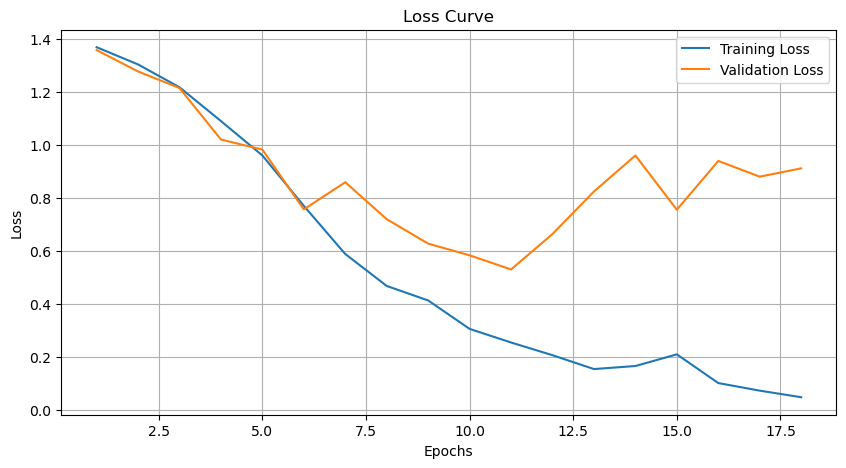

In [20]:
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model1.pth",
    csv_name="resnet50_training_results_earlystopping.csv", 
    use_weighted_loss=True
)

Inference: 100%|██████████| 8/8 [00:08<00:00,  1.11s/it]



Macro Precision: 0.7370, Macro Recall: 0.7333, Macro F1: 0.7200
Class 0 - Precision: 0.7500, Recall: 1.0000, F1-score: 0.8571
Class 1 - Precision: 0.7778, Recall: 0.4667, F1-score: 0.5833
Class 2 - Precision: 0.7059, Recall: 0.8000, F1-score: 0.7500
Class 3 - Precision: 0.7143, Recall: 0.6667, F1-score: 0.6897


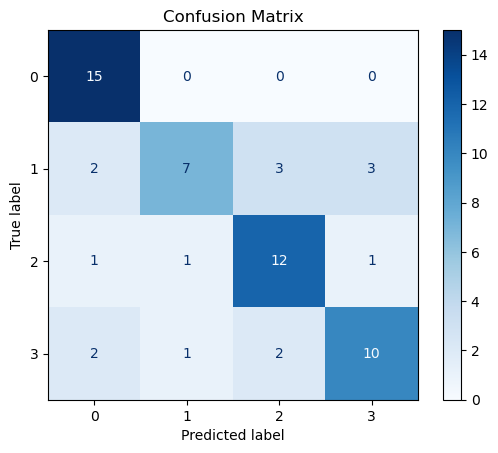

In [21]:
trainer.inference(model_path="best_model1.pth", dataloader=test_dataloader)

## ResNet-50 training
***Early Stopping*** + ***Cross Entropy Loss***

Epoch 1: 100%|██████████| 35/35 [01:43<00:00,  2.95s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3822
Accuracy: 0.2964
Macro Precision: 0.2425
Macro Recall: 0.2964
Macro F1 Score: 0.2511
Class 0 - Precision: 0.3902, Recall: 0.2286, F1-score: 0.2883
Class 1 - Precision: 0.2394, Recall: 0.4857, F1-score: 0.3208
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.3402, Recall: 0.4714, F1-score: 0.3952


Val Epoch 1: 100%|██████████| 8/8 [00:09<00:00,  1.22s/it]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.3637, Accuracy: 0.5833
Macro Precision: 0.4899
Macro Recall: 0.5833
Macro F1 Score: 0.5114
Class 0 - Precision: 0.8182, Recall: 0.6000, F1-score: 0.6923
Class 1 - Precision: 0.4194, Recall: 0.8667, F1-score: 0.5652
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.7222, Recall: 0.8667, F1-score: 0.7879


Epoch 2: 100%|██████████| 35/35 [01:47<00:00,  3.07s/it]


...


--- Validation Metrics (Epoch 19) ---
Val Loss: 1.0691, Accuracy: 0.7833
Macro Precision: 0.7865
Macro Recall: 0.7833
Macro F1 Score: 0.7835
Class 0 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 1 - Precision: 0.7500, Recall: 0.8000, F1-score: 0.7742
Class 2 - Precision: 0.8462, Recall: 0.7333, F1-score: 0.7857
Class 3 - Precision: 0.7500, Recall: 0.8000, F1-score: 0.7742


Epoch 20: 100%|██████████| 35/35 [01:41<00:00,  2.89s/it]



--- Training Metrics (Epoch 20) ---
Train Loss: 0.0741
Accuracy: 0.9750
Macro Precision: 0.9752
Macro Recall: 0.9750
Macro F1 Score: 0.9748
Class 0 - Precision: 0.9718, Recall: 0.9857, F1-score: 0.9787
Class 1 - Precision: 0.9848, Recall: 0.9286, F1-score: 0.9559
Class 2 - Precision: 0.9859, Recall: 1.0000, F1-score: 0.9929
Class 3 - Precision: 0.9583, Recall: 0.9857, F1-score: 0.9718


Val Epoch 20: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]



--- Validation Metrics (Epoch 20) ---
Val Loss: 0.7829, Accuracy: 0.8333
Macro Precision: 0.8348
Macro Recall: 0.8333
Macro F1 Score: 0.8331
Class 0 - Precision: 0.8571, Recall: 0.8000, F1-score: 0.8276
Class 1 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 2 - Precision: 0.8571, Recall: 0.8000, F1-score: 0.8276
Class 3 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Early stopping triggered.


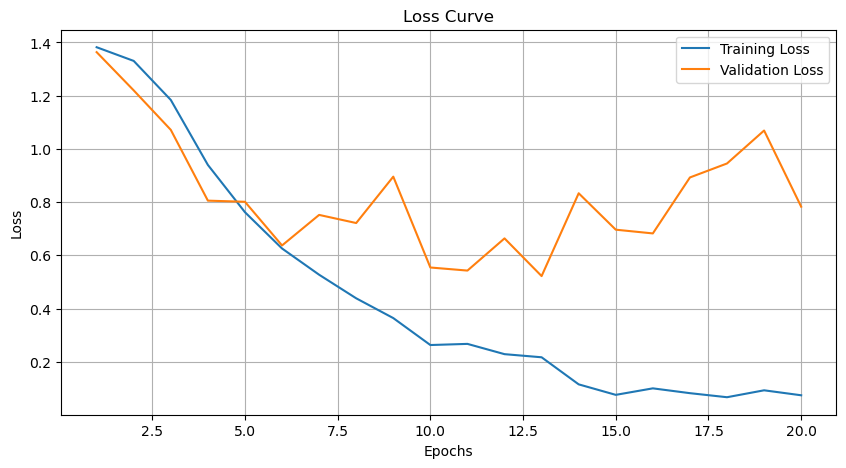

In [22]:
trainer = ResNet50Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model1.pth",
    csv_name="resnet50_training_results_earlystopping_withoutweight.csv", 
    use_weighted_loss=False
)

Inference: 100%|██████████| 8/8 [00:09<00:00,  1.22s/it]



Macro Precision: 0.7628, Macro Recall: 0.7667, Macro F1: 0.7599
Class 0 - Precision: 0.7895, Recall: 1.0000, F1-score: 0.8824
Class 1 - Precision: 0.6923, Recall: 0.6000, F1-score: 0.6429
Class 2 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 3 - Precision: 0.7692, Recall: 0.6667, F1-score: 0.7143


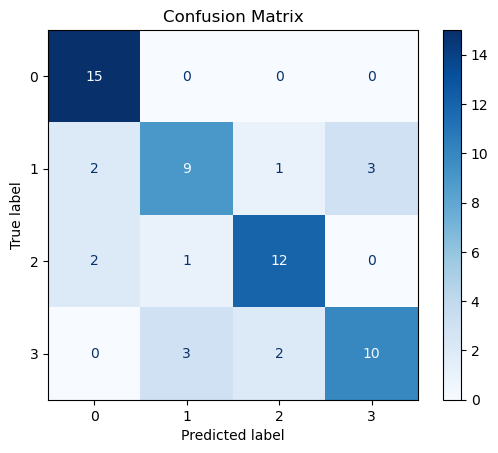

In [23]:
trainer.inference(model_path="best_model1.pth", dataloader=test_dataloader)

## ResNet-18 Training
***Early Stopping*** + ***Cross Enropy Loss***

Epoch 1: 100%|██████████| 35/35 [00:56<00:00,  1.62s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3573
Accuracy: 0.2750
Macro Precision: 0.4125
Macro Recall: 0.2750
Macro F1 Score: 0.2095
Class 0 - Precision: 0.7500, Recall: 0.0429, F1-score: 0.0811
Class 1 - Precision: 0.2609, Recall: 0.7714, F1-score: 0.3899
Class 2 - Precision: 0.2642, Recall: 0.2000, F1-score: 0.2276
Class 3 - Precision: 0.3750, Recall: 0.0857, F1-score: 0.1395


Val Epoch 1: 100%|██████████| 8/8 [00:07<00:00,  1.07it/s]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.2649, Accuracy: 0.3333
Macro Precision: 0.3194
Macro Recall: 0.3333
Macro F1 Score: 0.2337
Class 0 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 1 - Precision: 0.2778, Recall: 1.0000, F1-score: 0.4348
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 1.0000, Recall: 0.3333, F1-score: 0.5000


Epoch 2: 100%|██████████| 35/35 [00:49<00:00,  1.41s/it]


...


--- Validation Metrics (Epoch 29) ---
Val Loss: 0.5859, Accuracy: 0.8500
Macro Precision: 0.8571
Macro Recall: 0.8500
Macro F1 Score: 0.8469
Class 0 - Precision: 0.8667, Recall: 0.8667, F1-score: 0.8667
Class 1 - Precision: 0.8750, Recall: 0.9333, F1-score: 0.9032
Class 2 - Precision: 0.9091, Recall: 0.6667, F1-score: 0.7692
Class 3 - Precision: 0.7778, Recall: 0.9333, F1-score: 0.8485


Epoch 30: 100%|██████████| 35/35 [00:44<00:00,  1.28s/it]



--- Training Metrics (Epoch 30) ---
Train Loss: 0.0084
Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1 Score: 1.0000
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 2 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 3 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000


Val Epoch 30: 100%|██████████| 8/8 [00:05<00:00,  1.39it/s]



--- Validation Metrics (Epoch 30) ---
Val Loss: 0.5193, Accuracy: 0.8500
Macro Precision: 0.8622
Macro Recall: 0.8500
Macro F1 Score: 0.8504
Class 0 - Precision: 0.8667, Recall: 0.8667, F1-score: 0.8667
Class 1 - Precision: 0.9286, Recall: 0.8667, F1-score: 0.8966
Class 2 - Precision: 0.9167, Recall: 0.7333, F1-score: 0.8148
Class 3 - Precision: 0.7368, Recall: 0.9333, F1-score: 0.8235


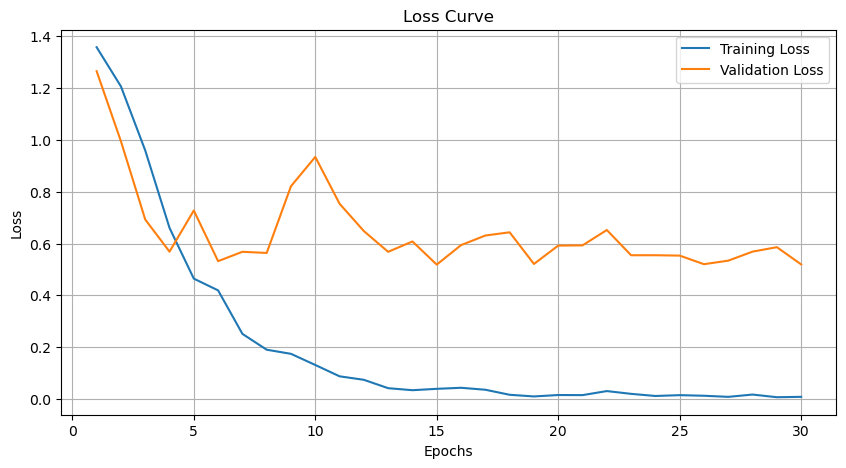

In [25]:
trainer = ResNet18Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model_resnet18_custom.pth",
    csv_name="resnet18_training_results_earlystopping_wihoutweight.csv", 
    use_weighted_loss=False
)

Inference: 100%|██████████| 8/8 [00:05<00:00,  1.35it/s]



Macro Precision: 0.8260, Macro Recall: 0.8167, Macro F1: 0.8174
Class 0 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 1 - Precision: 0.9231, Recall: 0.8000, F1-score: 0.8571
Class 2 - Precision: 0.7222, Recall: 0.8667, F1-score: 0.7879
Class 3 - Precision: 0.8462, Recall: 0.7333, F1-score: 0.7857


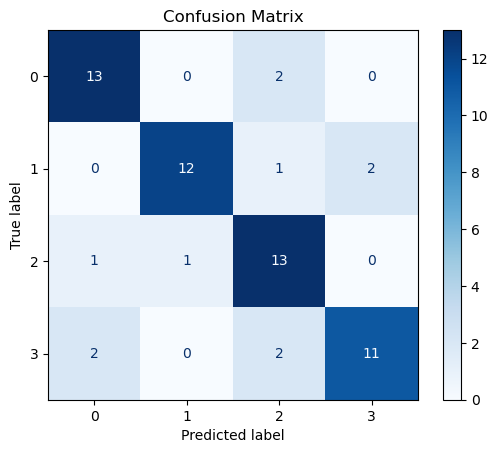

In [26]:
trainer.inference(model_path="best_model_resnet18_custom.pth", dataloader=test_dataloader)

## ResNet-18 Training

***Early Stopping*** + ***Weighted Cross Enropy Loss***

Epoch 1: 100%|██████████| 35/35 [00:45<00:00,  1.30s/it]



--- Training Metrics (Epoch 1) ---
Train Loss: 1.3519
Accuracy: 0.2786
Macro Precision: 0.6481
Macro Recall: 0.2786
Macro F1 Score: 0.1567
Class 0 - Precision: 0.8333, Recall: 0.0714, F1-score: 0.1316
Class 1 - Precision: 0.2593, Recall: 1.0000, F1-score: 0.4118
Class 2 - Precision: 0.5000, Recall: 0.0143, F1-score: 0.0278
Class 3 - Precision: 1.0000, Recall: 0.0286, F1-score: 0.0556


Val Epoch 1: 100%|██████████| 8/8 [00:05<00:00,  1.35it/s]



--- Validation Metrics (Epoch 1) ---
Val Loss: 1.2511, Accuracy: 0.2500
Macro Precision: 0.0625
Macro Recall: 0.2500
Macro F1 Score: 0.1000
Class 0 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 1 - Precision: 0.2500, Recall: 1.0000, F1-score: 0.4000
Class 2 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000
Class 3 - Precision: 0.0000, Recall: 0.0000, F1-score: 0.0000


Epoch 2: 100%|██████████| 35/35 [00:44<00:00,  1.27s/it]


...


--- Validation Metrics (Epoch 29) ---
Val Loss: 0.8250, Accuracy: 0.8000
Macro Precision: 0.8062
Macro Recall: 0.8000
Macro F1 Score: 0.7955
Class 0 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 1 - Precision: 0.8571, Recall: 0.8000, F1-score: 0.8276
Class 2 - Precision: 0.8182, Recall: 0.6000, F1-score: 0.6923
Class 3 - Precision: 0.7368, Recall: 0.9333, F1-score: 0.8235


Epoch 30: 100%|██████████| 35/35 [00:58<00:00,  1.67s/it]



--- Training Metrics (Epoch 30) ---
Train Loss: 0.0165
Accuracy: 0.9964
Macro Precision: 0.9965
Macro Recall: 0.9964
Macro F1 Score: 0.9964
Class 0 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 1 - Precision: 0.9859, Recall: 1.0000, F1-score: 0.9929
Class 2 - Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Class 3 - Precision: 1.0000, Recall: 0.9857, F1-score: 0.9928


Val Epoch 30: 100%|██████████| 8/8 [00:06<00:00,  1.27it/s]



--- Validation Metrics (Epoch 30) ---
Val Loss: 0.6941, Accuracy: 0.8167
Macro Precision: 0.8188
Macro Recall: 0.8167
Macro F1 Score: 0.8115
Class 0 - Precision: 0.8667, Recall: 0.8667, F1-score: 0.8667
Class 1 - Precision: 0.8125, Recall: 0.8667, F1-score: 0.8387
Class 2 - Precision: 0.8182, Recall: 0.6000, F1-score: 0.6923
Class 3 - Precision: 0.7778, Recall: 0.9333, F1-score: 0.8485


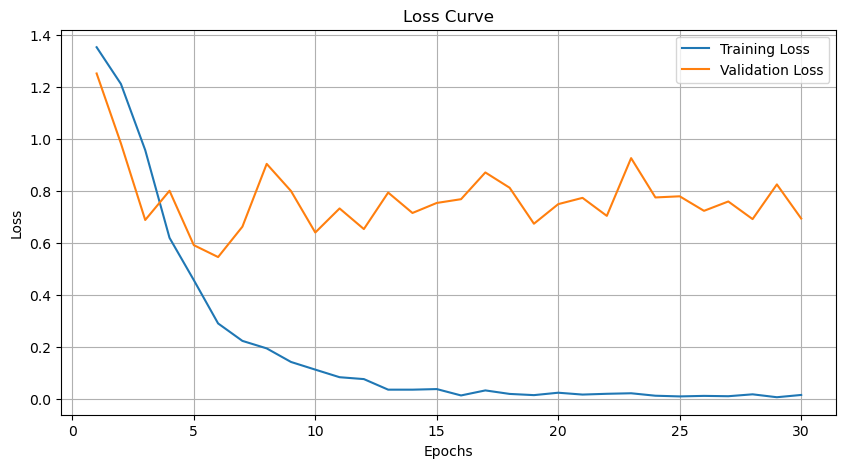

In [27]:
trainer = ResNet18Trainer(num_classes=config.num_classes, device=device, config=config)
trainer.train(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    model_path="best_model_resnet18_custom.pth",
    csv_name="resnet18_training_results_earlystopping_wihoutweight.csv", 
    use_weighted_loss=True
)

Inference: 100%|██████████| 8/8 [00:06<00:00,  1.29it/s]



Macro Precision: 0.8114, Macro Recall: 0.8000, Macro F1: 0.7957
Class 0 - Precision: 0.8235, Recall: 0.9333, F1-score: 0.8750
Class 1 - Precision: 0.7222, Recall: 0.8667, F1-score: 0.7879
Class 2 - Precision: 0.8000, Recall: 0.8000, F1-score: 0.8000
Class 3 - Precision: 0.9000, Recall: 0.6000, F1-score: 0.7200


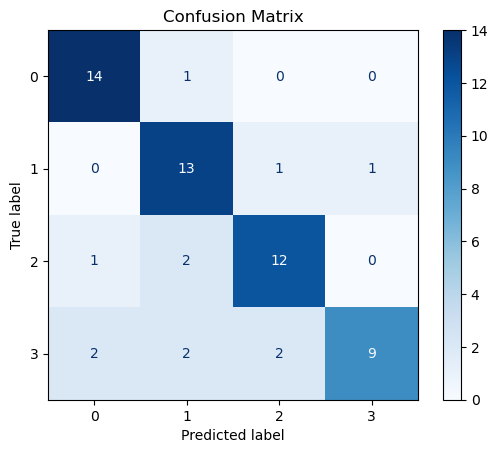

In [28]:
trainer.inference(model_path="best_model_resnet18_custom.pth", dataloader=test_dataloader)